# How to Win the VN1 Competition

## MLForecast

In [1]:
import lightgbm as lgb
import pandas as pd
from mlforecast import MLForecast
from mlforecast.lag_transforms import ExpandingMean, RollingMean, RollingStd
from mlforecast.target_transforms import LocalRobustScaler
from utilsforecast.plotting import plot_series

In [2]:
# Load prepared data
df = pd.read_parquet('../data_prepared/df.parquet')
df.head()

,unique_id,ds,y
0,0-1-10705,2020-07-06,7.0
1,0-1-10705,2020-07-13,7.0
2,0-1-10705,2020-07-20,7.0
3,0-1-10705,2020-07-27,7.0
4,0-1-10705,2020-08-03,7.0


### Model Configuration

We configure MLForecast with:
- **Lags**: 13 and 52 weeks (quarterly and yearly seasonality)
- **Lag transforms**: Rolling means, rolling std, and expanding mean to capture trends and variability
- **Target transform**: Robust scaling with IQR for handling outliers
- **Date features**: Year and month for capturing temporal patterns
- **Model**: LightGBM with tuned hyperparameters

In [3]:
# Forecast horizon
h = 13

# Define lag transforms
rmean4 = RollingMean(window_size=4, min_samples=1)
rstd4 = RollingStd(window_size=4, min_samples=2)

# LightGBM model with tuned hyperparameters
lgb_params = {
    'verbosity': -1,
    'learning_rate': 0.2,
    'num_leaves': 128,
    'n_estimators': 500
}

# Create MLForecast instance
mlf = MLForecast(
    models=[lgb.LGBMRegressor(**lgb_params)],
    freq='W-MON',
    lags=[13, 52],
    lag_transforms={
        1: [
            ExpandingMean(),
            rmean4,
            rstd4,
            RollingMean(window_size=13, min_samples=1),
            RollingMean(window_size=26, min_samples=1),
            RollingMean(window_size=52, min_samples=1),
        ],
        4: [rmean4, rstd4, RollingMean(window_size=48, min_samples=1)],
        8: [rmean4, rstd4, RollingMean(window_size=44, min_samples=1)],
        13: [rmean4, rstd4, RollingMean(window_size=39, min_samples=1)],
    },
    target_transforms=[LocalRobustScaler(scale='iqr')],
    date_features=['year', 'month'],
    num_threads=4,
)

### Model Fitting and Forecasting

In [4]:
# Fit the model
mlf.fit(df, dropna=False)

MLForecast(models=[LGBMRegressor], freq=W-MON, lag_features=['lag13', 'lag52', 'expanding_mean_lag1', 'rolling_mean_lag1_window_size4_min_samples1', 'rolling_std_lag1_window_size4_min_samples2', 'rolling_mean_lag1_window_size13_min_samples1', 'rolling_mean_lag1_window_size26_min_samples1', 'rolling_mean_lag1_window_size52_min_samples1', 'rolling_mean_lag4_window_size4_min_samples1', 'rolling_std_lag4_window_size4_min_samples2', 'rolling_mean_lag4_window_size48_min_samples1', 'rolling_mean_lag8_window_size4_min_samples1', 'rolling_std_lag8_window_size4_min_samples2', 'rolling_mean_lag8_window_size44_min_samples1', 'rolling_mean_lag13_window_size4_min_samples1', 'rolling_std_lag13_window_size4_min_samples2', 'rolling_mean_lag13_window_size39_min_samples1'], date_features=['year', 'month'], num_threads=4)

In [8]:
# Generate forecasts
# fc_ml = mlf.predict(h=h)
# fc_ml.head()

In [9]:
fc_ml = pd.read_parquet('../output/fc_ml.parquet')

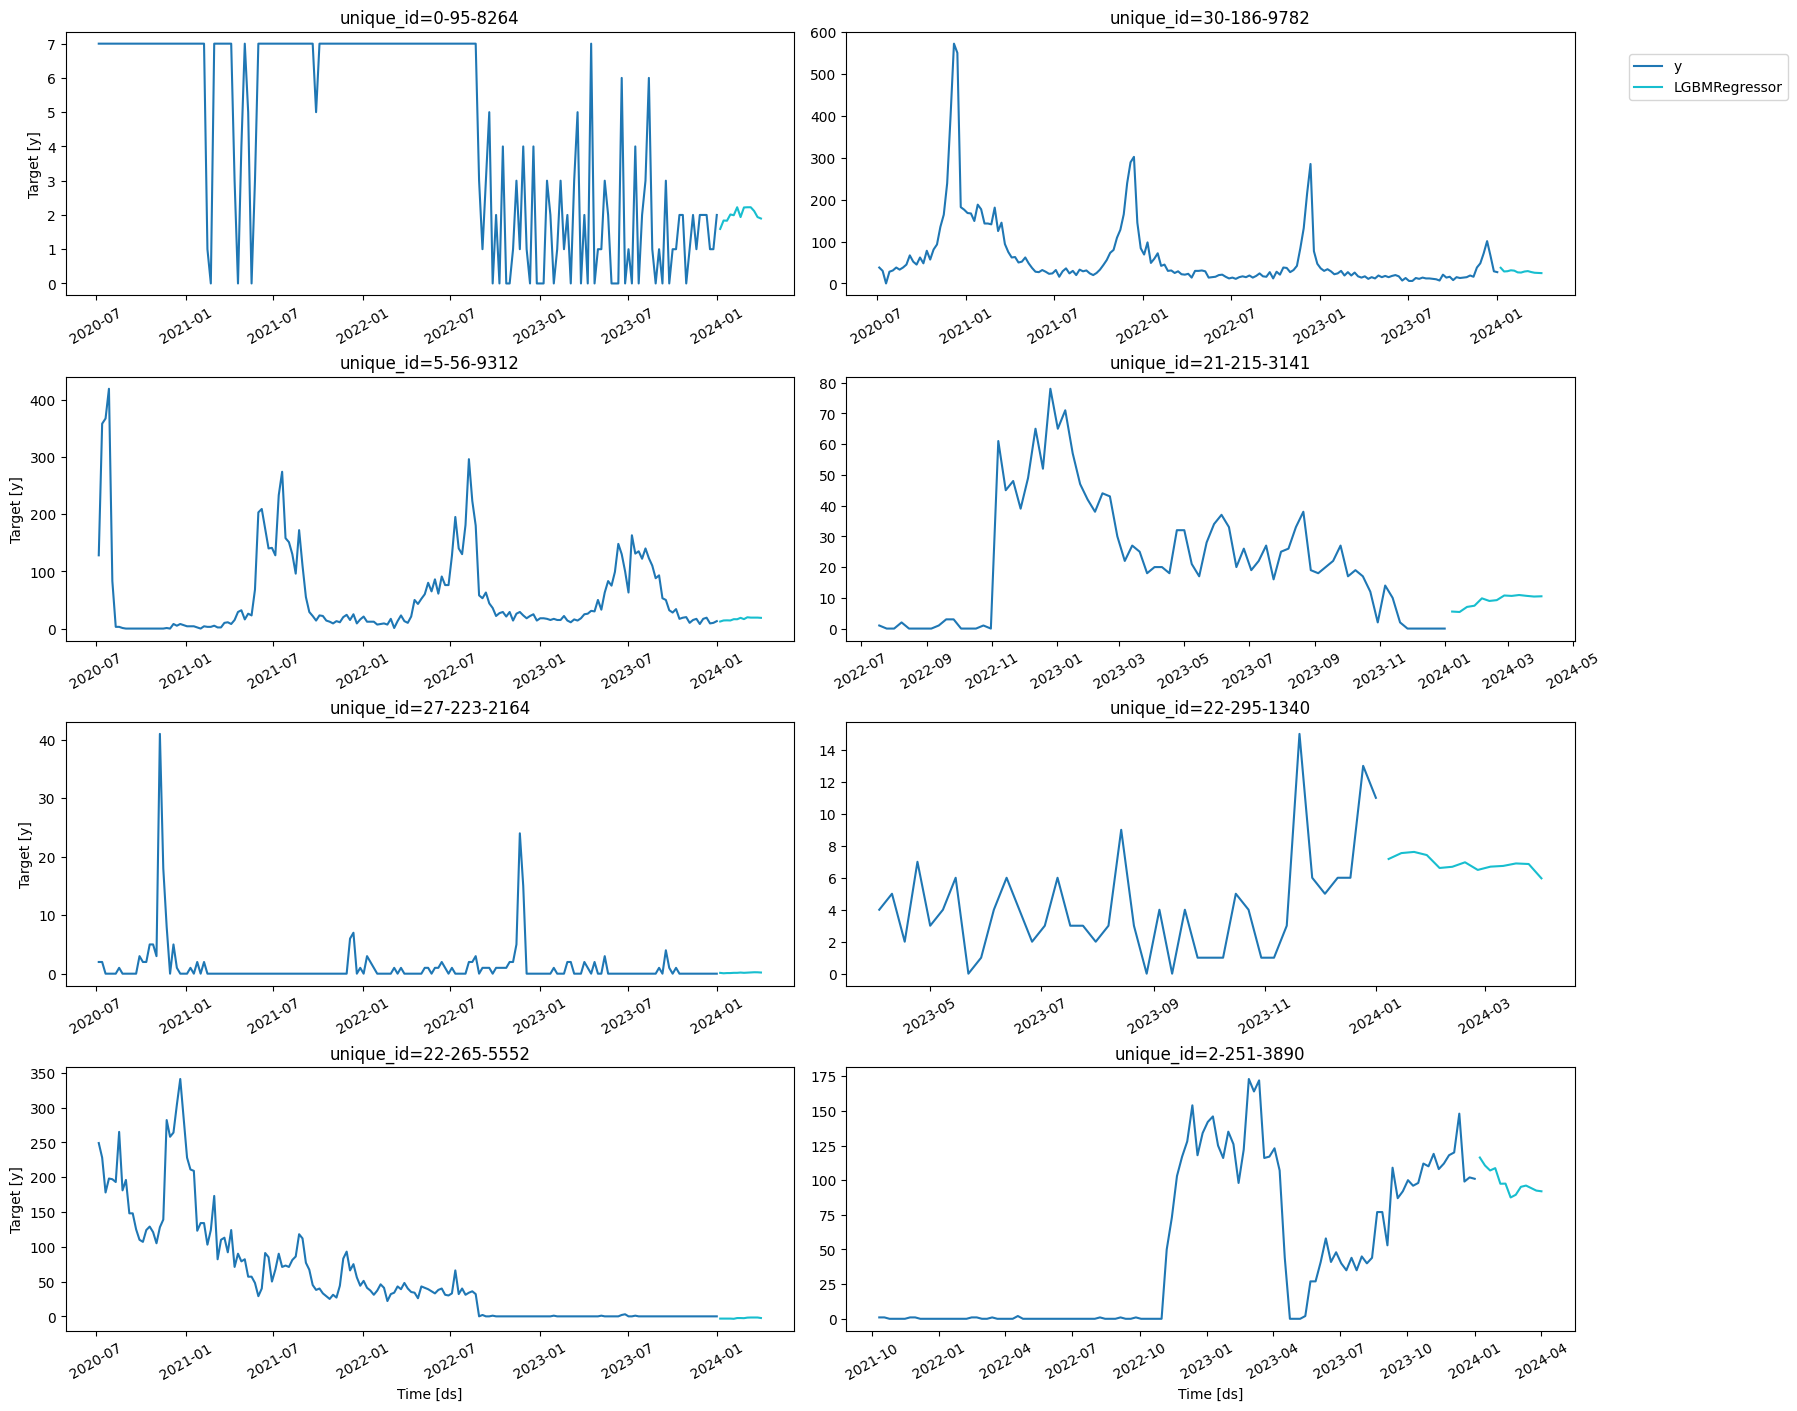

In [10]:
plot_series(df, fc_ml)

In [11]:
from utils import vn1_competition_evaluation

ml_scores = vn1_competition_evaluation(fc_ml)

In [12]:
winners_scores = pd.read_parquet('../scores/winners_scores.parquet')

results = pd.concat([winners_scores, ml_scores])
results.sort_values(by='score').reset_index(drop=True)

,model,score
0,1st place,0.46375
1,2nd place,0.46568
2,3rd place,0.47578
3,4th place,0.47743
4,5th place,0.48081
5,LGBMRegressor,0.59453
